# Improvement Model Demo With Grad-CAM
This notebook compares the baseline DAViT model vs the improved model and visualizes Grad-CAM heatmaps.

## 1) Set Up Environment and Reproducibility

In [3]:
import os
import random
import glob
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
from transformers import AutoImageProcessor, AutoModel

# Reproducibility
seed = 123456
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/muddassir/miniconda/envs/cuda_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2) Load Model and Weights

In [6]:
import sys

# Local modules
sys.path.append(os.path.join(os.getcwd(), "DAViT", "davit"))

from model_davit import Model as BaselineModel  # noqa: E402
from improved_model import Model as ImprovedModel  # noqa: E402

model_name_or_path = "facebook/dinov2-large"

baseline_weights_path = os.path.join(
    "DAViT",
    "davit",
    "saved_models",
    "checkpoint-best-f1",
    "domain_adapted_davit.bin",
)

improved_weights_path = os.path.join(
    "DAViT",
    "davit",
    "saved_models",
    "checkpoint-best-f1",
    "davit_pneumonia_detection.bin",
)

processor = AutoImageProcessor.from_pretrained(model_name_or_path)

vit_base = AutoModel.from_pretrained(model_name_or_path)
vit_improved = AutoModel.from_pretrained(model_name_or_path)

# Dummy args holder
class Args:
    focal_gamma = 2.0
    focal_alpha = -1.0

args = Args()

baseline_model = BaselineModel(vit_base, processor, args).to(device)
improved_model = ImprovedModel(vit_improved, processor, args).to(device)


def filter_state_dict(model, state_dict):
    model_state = model.state_dict()
    filtered = {}
    for name, weights in state_dict.items():
        if name in model_state and model_state[name].shape == weights.shape:
            filtered[name] = weights
    return filtered


# Load weights if present
if os.path.exists(baseline_weights_path):
    baseline_state = torch.load(baseline_weights_path, map_location=device)
    baseline_model.load_state_dict(filter_state_dict(baseline_model, baseline_state), strict=False)

if os.path.exists(improved_weights_path):
    improved_state = torch.load(improved_weights_path, map_location=device)
    improved_model.load_state_dict(filter_state_dict(improved_model, improved_state), strict=False)

baseline_model.eval()
improved_model.eval()

print("Baseline weights found:", os.path.exists(baseline_weights_path))
print("Improved weights found:", os.path.exists(improved_weights_path))

Loading weights: 100%|██████████| 439/439 [00:00<00:00, 1410.91it/s]


Baseline weights found: True
Improved weights found: True


## 3) Load and Preprocess Images

In [7]:
data_root = os.path.join("data", "improvement_data", "test")
normal_paths = sorted(glob.glob(os.path.join(data_root, "NORMAL", "*.jpeg")))
pneumonia_paths = sorted(glob.glob(os.path.join(data_root, "PNEUMONIA", "*.jpeg")))

sample_paths = []
if normal_paths:
    sample_paths.append(normal_paths[0])
if pneumonia_paths:
    sample_paths.append(pneumonia_paths[0])

if not sample_paths:
    raise FileNotFoundError("No images found in data/improvement_data/test")

crop_size = (processor.size["shortest_edge"], processor.size["shortest_edge"])
preprocess = transforms.Compose([
    transforms.Resize(crop_size),
    transforms.CenterCrop(crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

raw_images = [Image.open(p).convert("RGB") for p in sample_paths]
input_tensors = torch.stack([preprocess(img) for img in raw_images]).to(device)
print("Loaded images:", sample_paths)

Loaded images: ['data/improvement_data/test/NORMAL/1312A392-67A3-4EBF-9319-810CF6DA5EF6.jpeg', 'data/improvement_data/test/PNEUMONIA/person1008_virus_1691.jpeg']


## 4) Run Baseline Inference

In [8]:
with torch.no_grad():
    baseline_probs = baseline_model(pixel_values=input_tensors)

baseline_preds = torch.argmax(baseline_probs, dim=1).tolist()
print("Baseline preds:", baseline_preds)
print("Baseline probs:", baseline_probs.detach().cpu().numpy())

Baseline preds: [1, 1]
Baseline probs: [[0.42621303 0.573787  ]
 [0.42787752 0.5721225 ]]


## 5) Implement Grad-CAM

In [9]:
def get_target_layer(model):
    return model.cnn.conv3


def grad_cam(model, input_tensor, class_idx=None):
    model.eval()
    activations = []
    gradients = []

    def fwd_hook(_, __, output):
        activations.append(output)

    def bwd_hook(_, grad_in, grad_out):
        gradients.append(grad_out[0])

    target_layer = get_target_layer(model)
    handle_fwd = target_layer.register_forward_hook(fwd_hook)
    handle_bwd = target_layer.register_full_backward_hook(bwd_hook)

    scores = model(pixel_values=input_tensor)
    if class_idx is None:
        class_idx = int(torch.argmax(scores, dim=1)[0])
    score = scores[0, class_idx]

    model.zero_grad(set_to_none=True)
    score.backward(retain_graph=True)

    handle_fwd.remove()
    handle_bwd.remove()

    act = activations[0]
    grad = gradients[0]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam[0, 0].detach().cpu().numpy(), class_idx

## 6) Generate Grad-CAM Heatmaps

In [10]:
baseline_cams = []
improved_cams = []
baseline_classes = []
improved_classes = []

for i in range(len(raw_images)):
    cam, cls = grad_cam(baseline_model, input_tensors[i:i+1])
    baseline_cams.append(cam)
    baseline_classes.append(cls)

    cam, cls = grad_cam(improved_model, input_tensors[i:i+1])
    improved_cams.append(cam)
    improved_classes.append(cls)

print("Baseline classes:", baseline_classes)
print("Improved classes:", improved_classes)

Baseline classes: [1, 1]
Improved classes: [0, 1]


## 7) Overlay Heatmaps on Images

In [11]:
def overlay_cam(pil_img, cam, alpha=0.4):
    img = np.array(pil_img)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cam_resized = cv2.resize(cam, (img_bgr.shape[1], img_bgr.shape[0]))
    cam_uint8 = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img_bgr, 1 - alpha, heatmap, alpha, 0)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay_rgb

baseline_overlays = [overlay_cam(img, cam) for img, cam in zip(raw_images, baseline_cams)]
improved_overlays = [overlay_cam(img, cam) for img, cam in zip(raw_images, improved_cams)]

## 8) Compare Baseline vs Improved Model

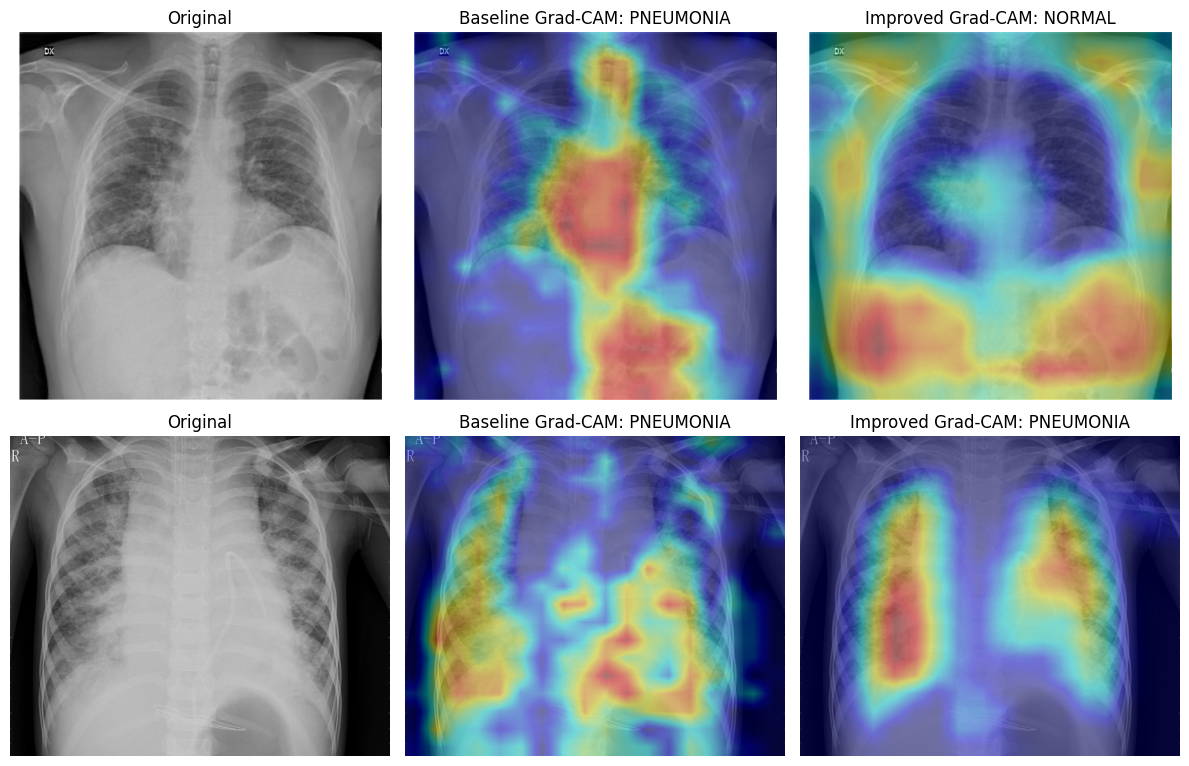

In [ ]:
labels = {0: "NORMAL", 1: "PNEUMONIA"}

def infer_true_label(path):
    parent = os.path.basename(os.path.dirname(path))
    return 0 if parent.upper() == "NORMAL" else 1

true_labels = [infer_true_label(p) for p in sample_paths]

fig, axes = plt.subplots(len(raw_images), 3, figsize=(12, 4 * len(raw_images)))
if len(raw_images) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, img in enumerate(raw_images):
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original (GT: {labels[true_labels[i]]})")
    axes[i, 0].axis("off")

    baseline_ok = baseline_classes[i] == true_labels[i]
    axes[i, 1].imshow(baseline_overlays[i])
    axes[i, 1].set_title(
        f"Baseline Grad-CAM: {labels.get(baseline_classes[i], baseline_classes[i])} | "
        f"Correct: {baseline_ok}"
    )
    axes[i, 1].axis("off")

    improved_ok = improved_classes[i] == true_labels[i]
    axes[i, 2].imshow(improved_overlays[i])
    axes[i, 2].set_title(
        f"Improved Grad-CAM: {labels.get(improved_classes[i], improved_classes[i])} | "
        f"Correct: {improved_ok}"
    )
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()